In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project 2 Runtime Environment active on: {device}")

Project 2 Runtime Environment active on: cuda


In [2]:
#Unique local dictionary mapping
vocabulary = {"<pad>": 0, "bright": 1, "dark": 2, "circle": 3, "square": 4}
reverse_vocabulary = {v: k for k, v in vocabulary.items()}

def execute_synthetic_batch_generator(batch_size=16):
    """
    Generates realistic 28x28 mathematical matrices of geometric structures
    accompanied by sequential word tokens without third-party asset loading.
    """
    canvas_batch = []
    linguistic_token_batch = []

    for _ in range(batch_size):
        image_canvas = np.zeros((28, 28), dtype=np.float32)

        #Determine visual intensity setting
        intensity_flag = np.random.rand() > 0.5
        pixel_weight = 0.8 if intensity_flag else 0.3
        descriptor_word = "bright" if intensity_flag else "dark"

        #Determine spatial configuration
        shape_flag = np.random.rand() > 0.5
        geometry_word = "circle" if shape_flag else "square"

        if shape_flag:
            #Construct a mathematical circle shape
            center_x, center_y, radius = 14, 14, 6
            grid_y, grid_x = np.ogrid[:28, :28]
            circle_mask = (grid_x - center_x)**2 + (grid_y - center_y)**2 <= radius**2
            image_canvas[circle_mask] = pixel_weight
        else:
            #Construct a mathematical square shape
            image_canvas[8:20, 8:20] = pixel_weight

        #Rescale array distribution values to standard GAN scale [-1, 1]
        normalized_canvas = (image_canvas * 2.0) - 1.0
        canvas_batch.append(normalized_canvas)

        #Convert raw strings directly to sequence token positions
        token_sequence = [vocabulary[descriptor_word], vocabulary[geometry_word]]
        linguistic_token_batch.append(token_sequence)

    tensor_images = torch.tensor(np.array(canvas_batch)).unsqueeze(1).to(device)
    tensor_tokens = torch.tensor(linguistic_token_batch, dtype=torch.long).to(device)

    return tensor_images, tensor_tokens

In [3]:
class DeepCrossAttentionBridge(nn.Module):
    def __init__(self, visual_channel_dim, text_embedding_dim, projection_subspace_dim):
        """
        Independent cross-attention mechanism matching queries (from images)
        against keys and values (from text representations).
        """
        super().__init__()
        self.subspace_dim = projection_subspace_dim

        self.query_transform = nn.Linear(visual_channel_dim, projection_subspace_dim)
        self.key_transform = nn.Linear(text_embedding_dim, projection_subspace_dim)
        self.value_transform = nn.Linear(text_embedding_dim, visual_channel_dim)

        self.normalization_scale = projection_subspace_dim ** 0.5

    def forward(self, structural_canvas_features, textual_word_embeddings):

        spatial_queries = self.query_transform(structural_canvas_features)
        linguistic_keys = self.key_transform(textual_word_embeddings)
        linguistic_values = self.value_transform(textual_word_embeddings)

        raw_affinity_scores = torch.bmm(
            spatial_queries,
            linguistic_keys.transpose(1, 2)
        ) / self.normalization_scale


        calculated_attention_weights = F.softmax(raw_affinity_scores, dim=-1)

        context_aware_canvas = torch.bmm(calculated_attention_weights, linguistic_values) # (B, Total_Pixels, Channels)

        return context_aware_canvas, calculated_attention_weights

In [4]:
class AttentionalGenerator(nn.Module):
    def __init__(self, noise_latent_dim, target_vocab_size, text_embedding_dim, sequence_length):
        super().__init__()
        self.token_embeddings = nn.Embedding(target_vocab_size, text_embedding_dim)


        self.seed_expansion = nn.Linear(noise_latent_dim, 7 * 7 * 64)

        self.attention_module = DeepCrossAttentionBridge(
            visual_channel_dim=64,
            text_embedding_dim=text_embedding_dim,
            projection_subspace_dim=32
        )

        self.upsample_convolution_1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.upsample_convolution_2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, noise_tensor, sequential_tokens):

        word_level_embeddings = self.token_embeddings(sequential_tokens) # (B, Seq_Len, Embed_Dim)

        latent_features = F.relu(self.seed_expansion(noise_tensor))
        flattened_spatial_features = latent_features.view(-1, 7 * 7, 64) # (B, Pixels, Channels)

        focused_features, multi_attention_maps = self.attention_module(
            flattened_spatial_features,
            word_level_embeddings
        )


        reconstructed_grid = focused_features.view(-1, 64, 7, 7)

        reconstructed_grid = F.relu(self.upsample_convolution_1(reconstructed_grid))
        synthesized_image_canvas = torch.tanh(self.upsample_convolution_2(reconstructed_grid))

        return synthesized_image_canvas, multi_attention_maps


class ConditionalDiscriminator(nn.Module):
    def __init__(self, target_vocab_size, text_embedding_dim):
        super().__init__()
        self.token_embeddings = nn.Embedding(target_vocab_size, text_embedding_dim)

        self.downsample_conv_1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.downsample_conv_2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)

        self.text_condition_projection = nn.Linear(text_embedding_dim, 7 * 7 * 64)


        self.validity_classifier = nn.Sequential(
            nn.Linear(7 * 7 * 64 * 2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_images, sequential_tokens):
        image_features = F.leaky_relu(self.downsample_conv_1(input_images), 0.2)
        image_features = F.leaky_relu(self.downsample_conv_2(image_features), 0.2)
        flat_image_features = image_features.view(-1, 7 * 7 * 64)

        word_level_embeddings = self.token_embeddings(sequential_tokens)
        global_sentence_context = torch.mean(word_level_embeddings, dim=1)
        projected_text_condition = F.leaky_relu(self.text_condition_projection(global_sentence_context), 0.2)

        fused_critic_tensor = torch.cat([flat_image_features, projected_text_condition], dim=1)
        adversarial_probability = self.validity_classifier(fused_critic_tensor)

        return adversarial_probability

Beginning Optimization Loop Process...
Step [001/150] -> Discriminator Loss: 1.3649 | Generator Loss: 0.8495
Step [050/150] -> Discriminator Loss: 0.0754 | Generator Loss: 3.6944
Step [100/150] -> Discriminator Loss: 0.0167 | Generator Loss: 5.9062
Step [150/150] -> Discriminator Loss: 0.0272 | Generator Loss: 5.2663


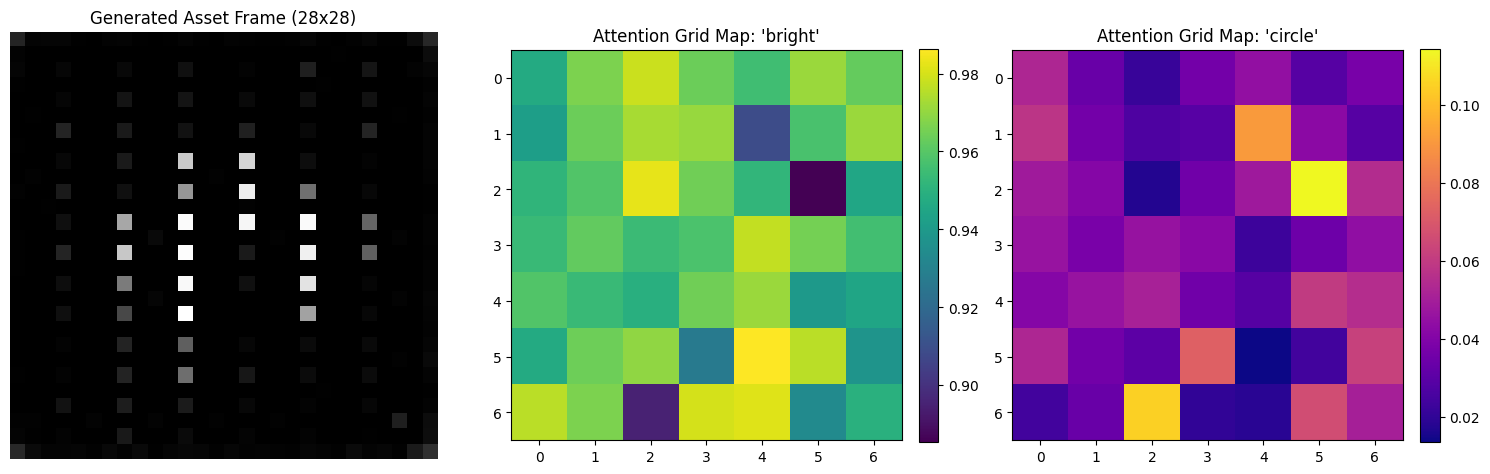

In [5]:

latent_dimensions = 100
embedding_dimensions = 50
token_sequence_length = 2

generator_network = AttentionalGenerator(latent_dimensions, len(vocabulary), embedding_dimensions, token_sequence_length).to(device)
discriminator_network = ConditionalDiscriminator(len(vocabulary), embedding_dimensions).to(device)

criterion_loss = nn.BCELoss()
optimizer_generator = optim.Adam(generator_network.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_discriminator = optim.Adam(discriminator_network.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Beginning Optimization Loop Process...")

#Fast Optimization Execution Loop
for epoch_index in range(1, 151):
    real_images, target_tokens = execute_synthetic_batch_generator(batch_size=16)
    current_batch_size = real_images.size(0)

    ground_truth_labels = torch.ones(current_batch_size, 1).to(device)
    synthetic_unreal_labels = torch.zeros(current_batch_size, 1).to(device)


    #Optimize Discriminator Node
    optimizer_discriminator.zero_grad()

    real_predictions = discriminator_network(real_images, target_tokens)
    loss_discriminator_real = criterion_loss(real_predictions, ground_truth_labels)

    latent_noise = torch.randn(current_batch_size, latent_dimensions).to(device)
    fake_images, _ = generator_network(latent_noise, target_tokens)

    fake_predictions = discriminator_network(fake_images.detach(), target_tokens)
    loss_discriminator_fake = criterion_loss(fake_predictions, synthetic_unreal_labels)

    total_loss_discriminator = loss_discriminator_real + loss_discriminator_fake
    total_loss_discriminator.backward()
    optimizer_discriminator.step()


    optimizer_generator.zero_grad()

    adversarial_evaluation = discriminator_network(fake_images, target_tokens)
    loss_generator = criterion_loss(adversarial_evaluation, ground_truth_labels)

    loss_generator.backward()
    optimizer_generator.step()

    if epoch_index % 50 == 0 or epoch_index == 1:
        print(f"Step [{epoch_index:03d}/150] -> Discriminator Loss: {total_loss_discriminator.item():.4f} | Generator Loss: {loss_generator.item():.4f}")

generator_network.eval()
test_noise = torch.randn(1, latent_dimensions).to(device)
test_token_sequence = torch.tensor([[vocabulary["bright"], vocabulary["circle"]]], dtype=torch.long).to(device)

with torch.no_grad():
    generated_output_frame, calculated_attention_maps = generator_network(test_noise, test_token_sequence)


attention_matrix_map = calculated_attention_maps[0].cpu().numpy()
attention_for_token_1 = attention_matrix_map[:, 0].reshape(7, 7)
attention_for_token_2 = attention_matrix_map[:, 1].reshape(7, 7)

#Render Plot Display Interface
fig, axes_subplots = plt.subplots(1, 3, figsize=(15, 5))

# Plot Sub-Canvas 1: Output Matrix
axes_subplots[0].imshow(generated_output_frame[0, 0].cpu().numpy(), cmap='gray')
axes_subplots[0].set_title("Generated Asset Frame (28x28)")
axes_subplots[0].axis('off')

#Plot Sub-Canvas 2: Word 1 Attention (Descriptor)
map_1 = axes_subplots[1].imshow(attention_for_token_1, cmap='viridis', interpolation='nearest')
axes_subplots[1].set_title(f"Attention Grid Map: '{reverse_vocabulary[test_token_sequence[0,0].item()]}'")
fig.colorbar(map_1, ax=axes_subplots[1], fraction=0.046, pad=0.04)

#Plot Sub-Canvas 3: Word 2 Attention (Geometry)
map_2 = axes_subplots[2].imshow(attention_for_token_2, cmap='plasma', interpolation='nearest')
axes_subplots[2].set_title(f"Attention Grid Map: '{reverse_vocabulary[test_token_sequence[0,1].item()]}'")
fig.colorbar(map_2, ax=axes_subplots[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()